In [46]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import joblib

In [47]:
df=pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [48]:
df['TotalCharges']=pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [49]:
df=df.dropna()

In [50]:
df.shape

(7032, 21)

In [51]:
df.drop(columns='customerID',inplace=True)

In [52]:
X=df.drop('Churn',axis=1)
y=df['Churn']

In [53]:
y=y.map({
    'No':0,
    "Yes":1
})

In [54]:
y.value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [55]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [56]:
categorical_cols=X.select_dtypes(
    include="object"
).columns.tolist()

In [57]:
numeric_cols=X.select_dtypes(
    exclude="object"
).columns.tolist()

In [58]:
preprocessor=ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        ),
        (
            "num",
            "passthrough",
            numeric_cols
        )
    ]
)

In [59]:
logistic_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",LogisticRegression(max_iter=1000))
])

In [60]:
logistic_pipeline.fit(X_train,y_train)

c:\Users\sdsha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [61]:
y_pred=logistic_pipeline.predict(X_test)
y_prob=logistic_pipeline.predict_proba(X_test)[:,1]

In [62]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8024164889836531
Precision: 0.6445783132530121
Recall   : 0.5721925133689839
F1 Score : 0.6062322946175638
ROC AUC  : 0.8364260163275026


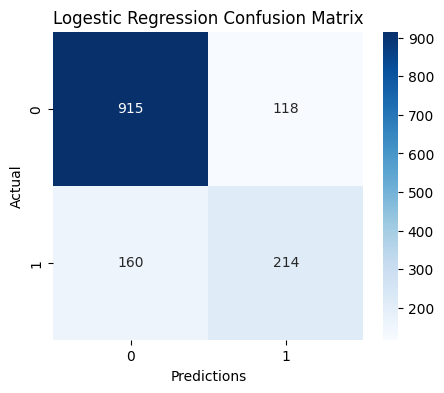

In [63]:
cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')
plt.xlabel("Predictions")
plt.ylabel("Actual")
plt.title("Logestic Regression Confusion Matrix")
plt.show()

In [64]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.64      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [65]:
rf_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ("model",RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

In [66]:
rf_pipeline.fit(X_train,y_train)
rf_pred=rf_pipeline.predict(X_test)
rf_prob=rf_pipeline.predict_proba(X_test)[:,1]

In [67]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC AUC  :", roc_auc_score(y_test, rf_prob))

Accuracy : 0.7867803837953091
Precision: 0.6241610738255033
Recall   : 0.49732620320855614
F1 Score : 0.5535714285714286
ROC AUC  : 0.8116526290178132


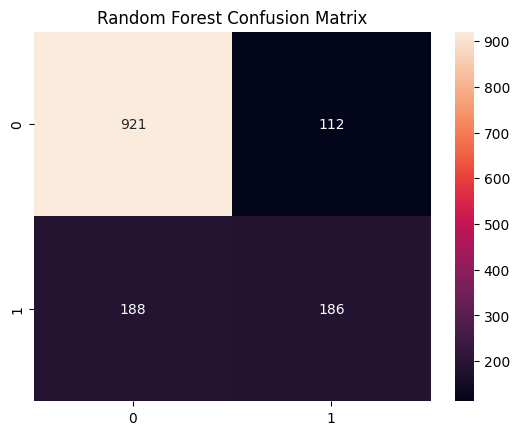

In [68]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [69]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.50      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [70]:
comparison = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest"],
    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,rf_pred)
    ],
    "Precision":[
        precision_score(y_test,y_pred),
        precision_score(y_test,rf_pred)
    ],
    "Recall":[
        recall_score(y_test,y_pred),
        recall_score(y_test,rf_pred)
    ],
    "F1":[
        f1_score(y_test,y_pred),
        f1_score(y_test,rf_pred)
    ],
    "ROC_AUC":[
        roc_auc_score(y_test,y_prob),
        roc_auc_score(y_test,rf_prob)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.802416,0.644578,0.572193,0.606232,0.836426
1,Random Forest,0.786780,0.624161,0.497326,0.553571,0.811653


In [71]:
xgb_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('model',XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        eval_metric='logloss'
    ))
])

xgb_pipeline.fit(X_train,y_train)
xgb_pred=xgb_pipeline.predict(X_test)
xgb_prob=xgb_pipeline.predict_proba(X_test)[:,1]

In [72]:
print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC AUC  :", roc_auc_score(y_test, xgb_prob))

Accuracy : 0.7967306325515281
Precision: 0.6392405063291139
Recall   : 0.5401069518716578
F1 Score : 0.5855072463768116
ROC AUC  : 0.8379790444735493


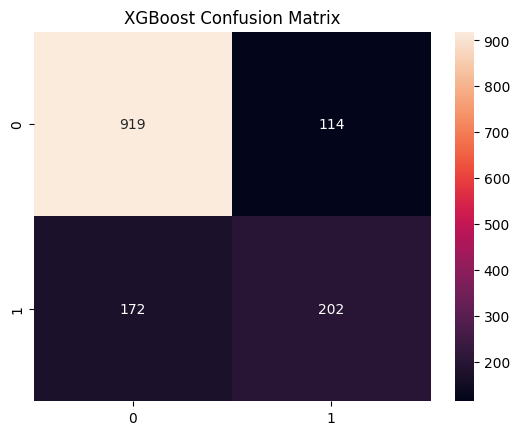

In [73]:
cm = confusion_matrix(y_test, xgb_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("XGBoost Confusion Matrix")
plt.show()

In [74]:
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.64      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



In [75]:
comparison = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest",'XGBoost'],
    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,xgb_pred)
    ],
    "Precision":[
        precision_score(y_test,y_pred),
        precision_score(y_test,rf_pred),
        precision_score(y_test,xgb_pred)
    ],
    "Recall":[
        recall_score(y_test,y_pred),
        recall_score(y_test,rf_pred),
        recall_score(y_test,xgb_pred)
    ],
    "F1":[
        f1_score(y_test,y_pred),
        f1_score(y_test,rf_pred),
        f1_score(y_test,xgb_pred)
    ],
    "ROC_AUC":[
        roc_auc_score(y_test,y_prob),
        roc_auc_score(y_test,rf_prob),
        roc_auc_score(y_test,xgb_prob)
    ]
})

In [76]:
comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.802416,0.644578,0.572193,0.606232,0.836426
1,Random Forest,0.786780,0.624161,0.497326,0.553571,0.811653
2,XGBoost,0.796731,0.639241,0.540107,0.585507,0.837979


In [77]:
lgbm_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('model',LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ))
])
lgbm_pipeline.fit(X_train,y_train)
lgbm_pred=lgbm_pipeline.predict(X_test)
lgbm_prob=lgbm_pipeline.predict_proba(X_test)[:,1]

[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000258 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 667
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151


c:\Users\sdsha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\sdsha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [78]:
print("Accuracy :", accuracy_score(y_test, lgbm_pred))
print("Precision:", precision_score(y_test, lgbm_pred))
print("Recall   :", recall_score(y_test, lgbm_pred))
print("F1 Score :", f1_score(y_test, lgbm_pred))
print("ROC AUC  :", roc_auc_score(y_test, lgbm_prob))

Accuracy : 0.7825159914712153
Precision: 0.6036585365853658
Recall   : 0.5294117647058824
F1 Score : 0.5641025641025641
ROC AUC  : 0.8317112817141289


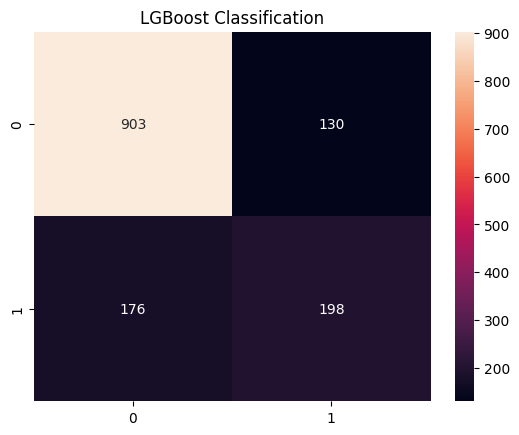

In [79]:
cm=confusion_matrix(y_test,lgbm_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d')
plt.title("LGBoost Classification")
plt.show()

In [80]:
print(classification_report(y_test,lgbm_pred))

              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1033
           1       0.60      0.53      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407



In [81]:
comparison = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest",'XGBoost','LGBoost'],
    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,xgb_pred),
        accuracy_score(y_test,lgbm_pred)
    ],
    "Precision":[
        precision_score(y_test,y_pred),
        precision_score(y_test,rf_pred),
        precision_score(y_test,xgb_pred),
        precision_score(y_test,lgbm_pred)
    ],
    "Recall":[
        recall_score(y_test,y_pred),
        recall_score(y_test,rf_pred),
        recall_score(y_test,xgb_pred),
        recall_score(y_test,lgbm_pred)
    ],
    "F1":[
        f1_score(y_test,y_pred),
        f1_score(y_test,rf_pred),
        f1_score(y_test,xgb_pred),
        f1_score(y_test,lgbm_pred)
    ],
    "ROC_AUC":[
        roc_auc_score(y_test,y_prob),
        roc_auc_score(y_test,rf_prob),
        roc_auc_score(y_test,xgb_prob),
        roc_auc_score(y_test,lgbm_prob)
    ]
})
comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.802416,0.644578,0.572193,0.606232,0.836426
1,Random Forest,0.786780,0.624161,0.497326,0.553571,0.811653
2,XGBoost,0.796731,0.639241,0.540107,0.585507,0.837979
3,LGBoost,0.782516,0.603659,0.529412,0.564103,0.831711


In [82]:
cat_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model",
     CatBoostClassifier(
         iterations=200,
         learning_rate=0.05,
         depth=6,
         verbose=0,
         random_state=42
     ))
])

cat_pipeline.fit(X_train, y_train)

cat_pred = cat_pipeline.predict(X_test)

cat_prob = cat_pipeline.predict_proba(X_test)[:,1]

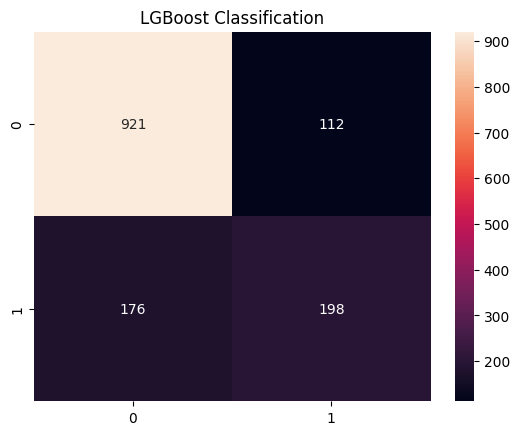

In [83]:
cm=confusion_matrix(y_test,cat_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d')
plt.title("LGBoost Classification")
plt.show()

In [84]:
print(classification_report(y_test,cat_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



In [85]:
comparison = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest",'XGBoost','LGBoost','CatBoost'],
    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,xgb_pred),
        accuracy_score(y_test,lgbm_pred),
        accuracy_score(y_test,cat_pred)
    ],
    "Precision":[
        precision_score(y_test,y_pred),
        precision_score(y_test,rf_pred),
        precision_score(y_test,xgb_pred),
        precision_score(y_test,lgbm_pred),
        precision_score(y_test,cat_pred)
    ],
    "Recall":[
        recall_score(y_test,y_pred),
        recall_score(y_test,rf_pred),
        recall_score(y_test,xgb_pred),
        recall_score(y_test,lgbm_pred),
        recall_score(y_test,cat_pred)
    ],
    "F1":[
        f1_score(y_test,y_pred),
        f1_score(y_test,rf_pred),
        f1_score(y_test,xgb_pred),
        f1_score(y_test,lgbm_pred),
        f1_score(y_test,cat_pred)
    ],
    "ROC_AUC":[
        roc_auc_score(y_test,y_prob),
        roc_auc_score(y_test,rf_prob),
        roc_auc_score(y_test,xgb_prob),
        roc_auc_score(y_test,lgbm_prob),
        roc_auc_score(y_test,cat_prob)
    ]
})
comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.802416,0.644578,0.572193,0.606232,0.836426
1,Random Forest,0.786780,0.624161,0.497326,0.553571,0.811653
2,XGBoost,0.796731,0.639241,0.540107,0.585507,0.837979
3,LGBoost,0.782516,0.603659,0.529412,0.564103,0.831711
4,CatBoost,0.795309,0.638710,0.529412,0.578947,0.834468


In [86]:
joblib.dump(
    logistic_pipeline,
    "../models/logistic_regression.pkl"
)
joblib.dump(
    xgb_pipeline,
    "../models/xgboost.pkl"
)
joblib.dump(
    cat_pipeline,
    "../models/catboost.pkl"
)

['../models/catboost.pkl']